In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load dataset from CSV file
data = pd.read_csv('S-W-D data.csv')

C:\Users\ompat\AppData\Local\Temp\ipykernel_6164\358336315.py:2: DtypeWarning: Columns (0,1,2,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('S-W-D data.csv')


In [3]:
# Display information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780468 entries, 0 to 780467
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Right_Temperature  780443 non-null  object
 1   Right_Pressure     780420 non-null  object
 2   Right_Humidity     780287 non-null  object
 3   Left_Temperature   780389 non-null  object
 4   Left_Pressure      780371 non-null  object
 5   Left_Humidity      780161 non-null  object
 6   Activity           780468 non-null  object
dtypes: object(7)
memory usage: 41.7+ MB


In [4]:
# Display the first few rows of the dataset
data.head(-1)

,Right_Temperature,Right_Pressure,Right_Humidity,Left_Temperature,Left_Pressure,Left_Humidity,Activity
0,30.55,911.4934,65.81,30.89,911.9968,71.88,W
1,30.55,911.4934,65.81,30.89,911.9968,71.88,W
2,30.55,911.4934,65.81,30.89,911.9968,71.88,W
3,30.59,911.452,67.15,30.98,912.0114,73.08,W
4,30.59,911.452,67.15,30.98,912.0114,73.08,W
...,...,...,...,...,...,...,...
780462,34.53,907.22,42.71,36.01,906.7706,54.66,D
780463,34.53,907.22,42.71,36.01,906.7706,54.66,D
780464,34.52,907.2164,42.71,36.01,906.7551,54.58,D
780465,34.52,907.2164,42.71,36.01,906.7551,54.58,D


In [5]:
# Generate descriptive statistics of the dataset
data.describe()

,Right_Temperature,Right_Pressure,Right_Humidity,Left_Temperature,Left_Pressure,Left_Humidity,Activity
count,780443,780420.0000,780287.00,780389.0,780371.000,780161.0,780468
unique,1297,69590.0000,6451.00,1234.0,66224.000,8323.0,3
top,33.63,915.5396,73.08,32.3,906.986,70.8,S
freq,2306,152.0000,622.00,2822.0,218.000,493.0,416551


In [6]:
# Get the column names of the dataset
data.columns

Index(['Right_Temperature', 'Right_Pressure', 'Right_Humidity',
       'Left_Temperature', 'Left_Pressure', 'Left_Humidity', 'Activity'],
      dtype='object')

In [7]:
# Convert specific columns to numeric type, handling errors with 'coerce'
columns_to_convert = ['Right_Temperature', 'Right_Pressure', 'Right_Humidity', 'Left_Temperature', 'Left_Pressure', 'Left_Humidity']
data[columns_to_convert] = data[columns_to_convert].apply(pd.to_numeric, errors='coerce')


In [8]:
# Generate descriptive statistics of the dataset
data.describe()

,Right_Temperature,Right_Pressure,Right_Humidity,Left_Temperature,Left_Pressure,Left_Humidity
count,780423.000000,780417.000000,780286.000000,780388.000000,780370.000000,780158.000000
mean,33.073887,913.604655,69.246528,33.785663,913.736295,75.326542
std,1.723074,5.729760,7.618727,1.686090,4.413271,15.456815
min,-118.570000,-145.697000,0.000000,-64.940000,-124.873100,0.000000
25%,31.840000,912.005500,66.460000,32.620000,912.131700,70.210000
50%,33.370000,914.137800,70.600000,33.910000,914.342600,74.850000
75%,34.020000,915.768700,74.090000,34.740000,916.136000,81.890000
max,921.907200,1521.499000,915.703700,921.372600,1506.677400,8222.000000


In [9]:
# Fill missing values with the mean of each column
columns_to_fill_with_mean = ['Right_Temperature', 'Right_Pressure', 'Right_Humidity', 'Left_Temperature', 'Left_Pressure', 'Left_Humidity']
data[columns_to_fill_with_mean] = data[columns_to_fill_with_mean].apply(pd.to_numeric, errors='coerce')
data[columns_to_fill_with_mean] = data[columns_to_fill_with_mean].fillna(data[columns_to_fill_with_mean].mean())

In [10]:
# Check for null values in the dataset
data.isnull().count()

Right_Temperature    780468
Right_Pressure       780468
Right_Humidity       780468
Left_Temperature     780468
Left_Pressure        780468
Left_Humidity        780468
Activity             780468
dtype: int64

In [11]:
# Display the first few rows of the dataset after data preprocessing
data.head(-1)

,Right_Temperature,Right_Pressure,Right_Humidity,Left_Temperature,Left_Pressure,Left_Humidity,Activity
0,30.55,911.4934,65.81,30.89,911.9968,71.88,W
1,30.55,911.4934,65.81,30.89,911.9968,71.88,W
2,30.55,911.4934,65.81,30.89,911.9968,71.88,W
3,30.59,911.4520,67.15,30.98,912.0114,73.08,W
4,30.59,911.4520,67.15,30.98,912.0114,73.08,W
...,...,...,...,...,...,...,...
780462,34.53,907.2200,42.71,36.01,906.7706,54.66,D
780463,34.53,907.2200,42.71,36.01,906.7706,54.66,D
780464,34.52,907.2164,42.71,36.01,906.7551,54.58,D
780465,34.52,907.2164,42.71,36.01,906.7551,54.58,D


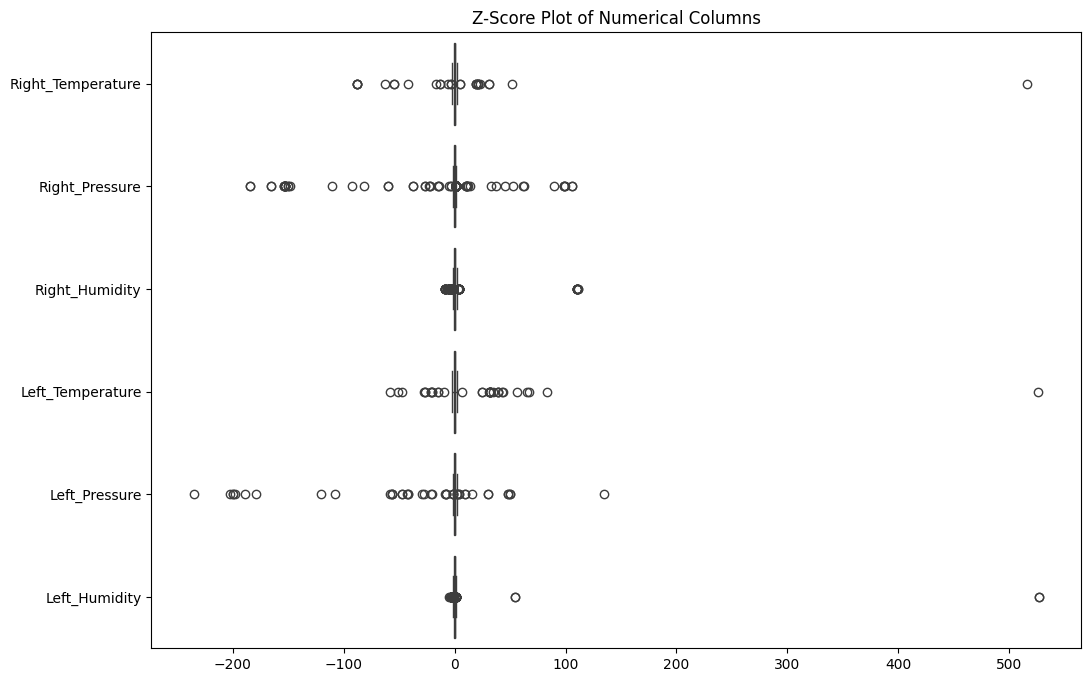

In [12]:
# Create a horizontal boxplot using Seaborn to visualize the distribution of z-scores
from scipy.stats import zscore

numerical_columns = ['Right_Temperature', 'Right_Pressure', 'Right_Humidity', 'Left_Temperature', 'Left_Pressure', 'Left_Humidity']
plt.figure(figsize=(12, 8))
z_scores = zscore(data[numerical_columns])
sns.boxplot(data=z_scores, orient='h')
plt.title('Z-Score Plot of Numerical Columns')
plt.show()


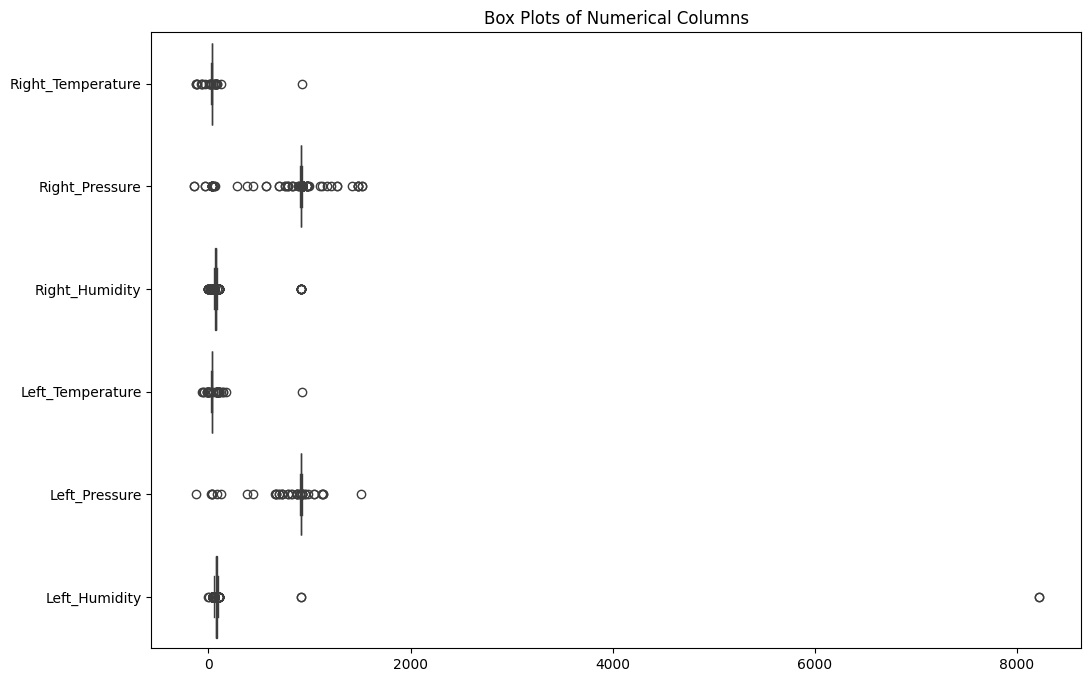

In [13]:
# Generate a horizontal boxplot using Seaborn to visualize the distribution of numerical columns
import matplotlib.pyplot as plt
import seaborn as sns

numerical_columns = ['Right_Temperature', 'Right_Pressure', 'Right_Humidity', 'Left_Temperature', 'Left_Pressure', 'Left_Humidity']

plt.figure(figsize=(12, 8))
sns.boxplot(data=data[numerical_columns], orient='h')
plt.title('Box Plots of Numerical Columns')
plt.show()


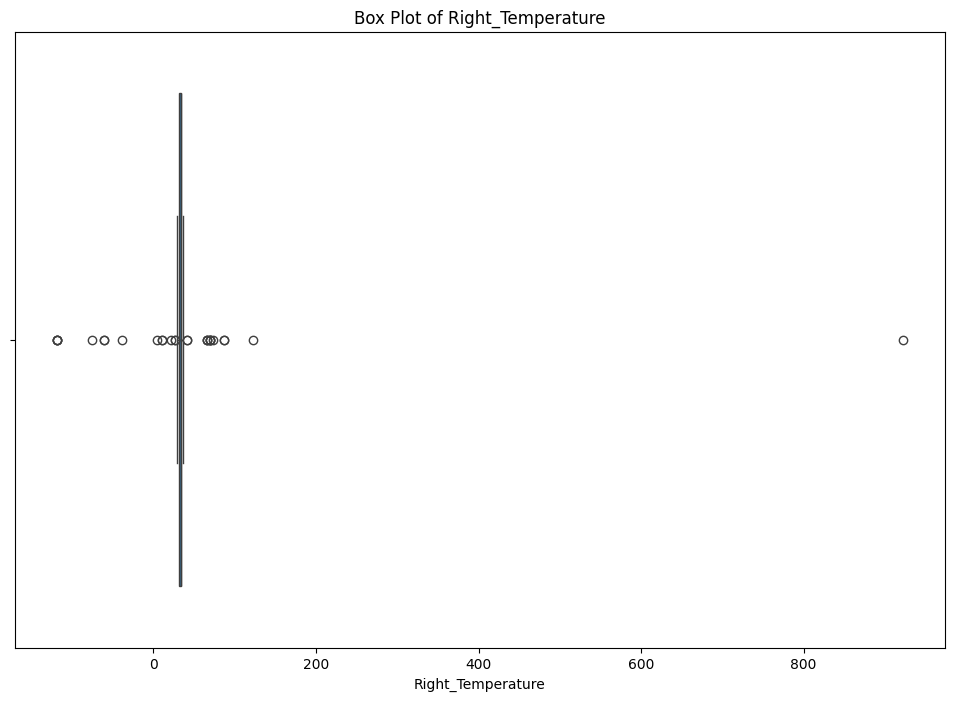

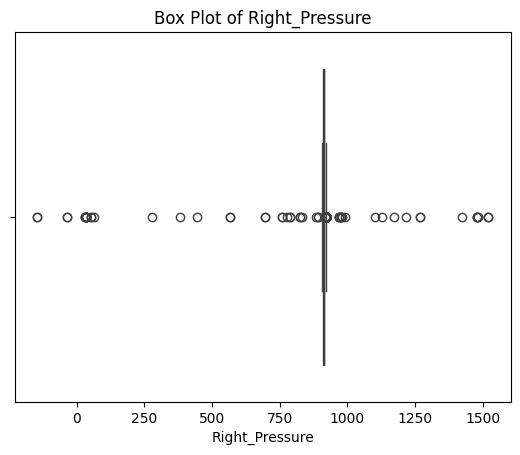

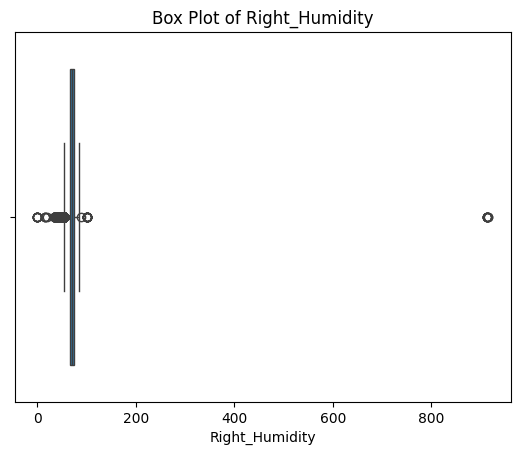

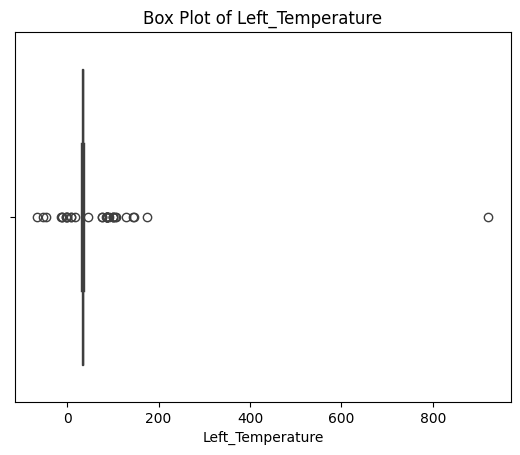

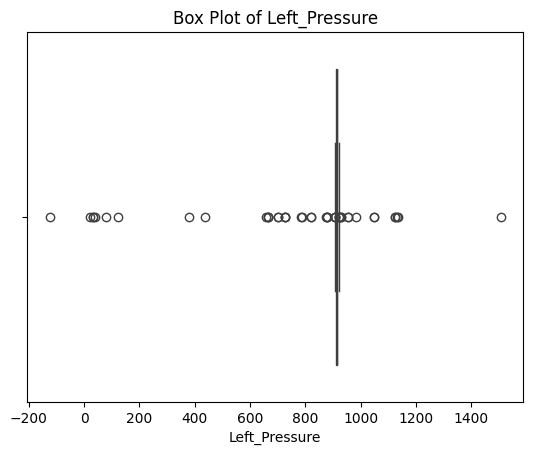

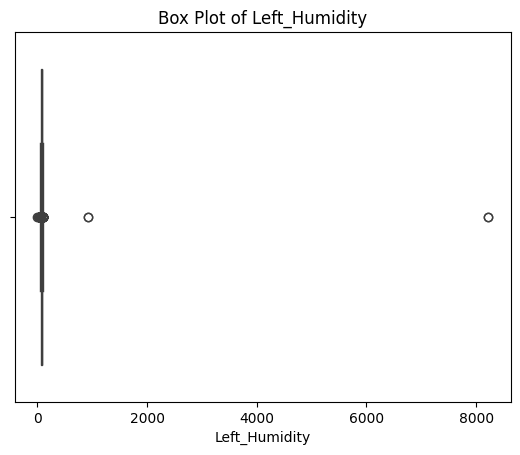

In [14]:
# Visualize box plots for numerical columns to identify outliers
numerical_columns = ['Right_Temperature', 'Right_Pressure', 'Right_Humidity', 'Left_Temperature', 'Left_Pressure', 'Left_Humidity']
plt.figure(figsize=(12, 8))
for column in numerical_columns:
    sns.boxplot(x=data[column])
    plt.title(f'Box Plot of {column}')
    plt.show()

In [15]:
# Remove outliers using the IQR method
iqr_multiplier = 1.5
for column in data.columns:
    if data[column].dtype in ['int64', 'float64']:
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - iqr_multiplier * IQR
        upper_bound = Q3 + iqr_multiplier * IQR
        data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

In [16]:
# Display the first few rows of the dataset after removing outliers
data.head(11)

,Right_Temperature,Right_Pressure,Right_Humidity,Left_Temperature,Left_Pressure,Left_Humidity,Activity
0,30.55,911.4934,65.81,30.89,911.9968,71.88,W
1,30.55,911.4934,65.81,30.89,911.9968,71.88,W
2,30.55,911.4934,65.81,30.89,911.9968,71.88,W
3,30.59,911.4520,67.15,30.98,912.0114,73.08,W
4,30.59,911.4520,67.15,30.98,912.0114,73.08,W
5,30.69,911.4304,68.69,31.14,911.9777,74.48,W
6,30.69,911.3741,70.23,31.37,911.9816,75.48,W
7,30.84,911.3741,70.23,31.37,911.9816,75.48,W
8,30.84,911.3741,70.23,31.37,911.9816,76.25,W
9,31.02,911.4299,71.47,31.61,911.9735,76.25,W


In [17]:
# Display descriptive statistics of the cleaned dataset
data.describe()

,Right_Temperature,Right_Pressure,Right_Humidity,Left_Temperature,Left_Pressure,Left_Humidity
count,724963.000000,724963.000000,724963.000000,724963.000000,724963.000000,724963.000000
mean,32.999635,913.848261,70.497010,33.704954,914.017277,76.090894
std,1.323274,2.651191,5.298574,1.267616,2.761685,7.422047
min,28.860000,907.088900,55.310000,30.020000,906.659200,53.580000
25%,31.710000,912.132300,67.500000,32.550000,912.266400,70.870000
50%,33.300000,914.311600,71.060000,33.810000,914.476800,75.330000
75%,33.940000,915.770800,74.340000,34.680000,916.138900,82.320000
max,36.270000,920.950300,84.630000,37.340000,920.073900,93.240000


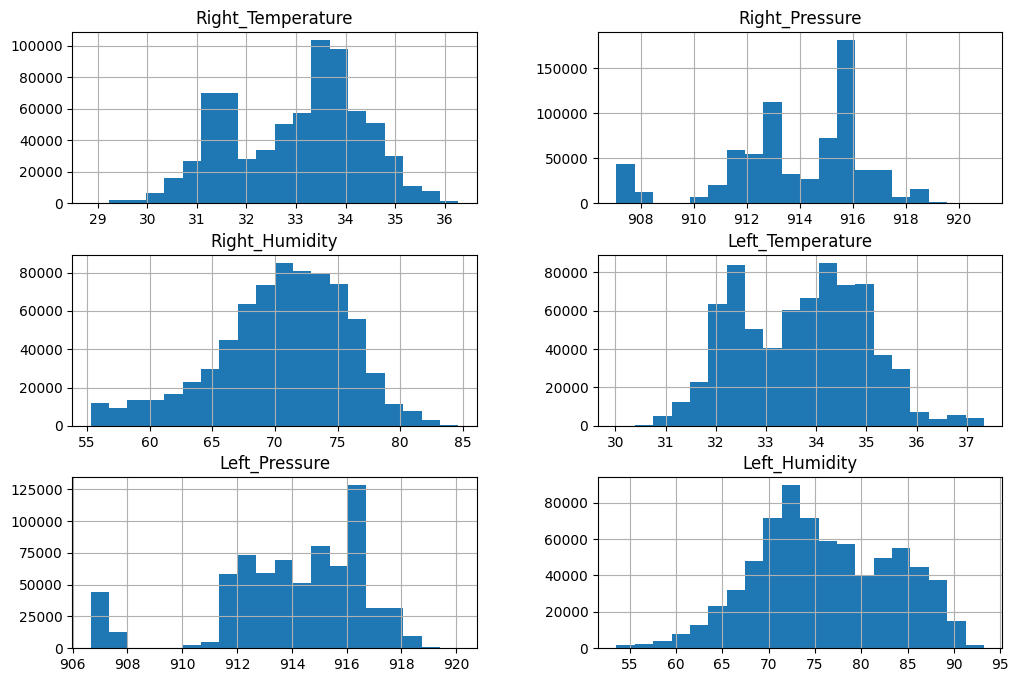

In [18]:
import matplotlib.pyplot as plt

# Visualize histograms for numerical columns
data.hist(bins=20, figsize=(12, 8))
plt.show()


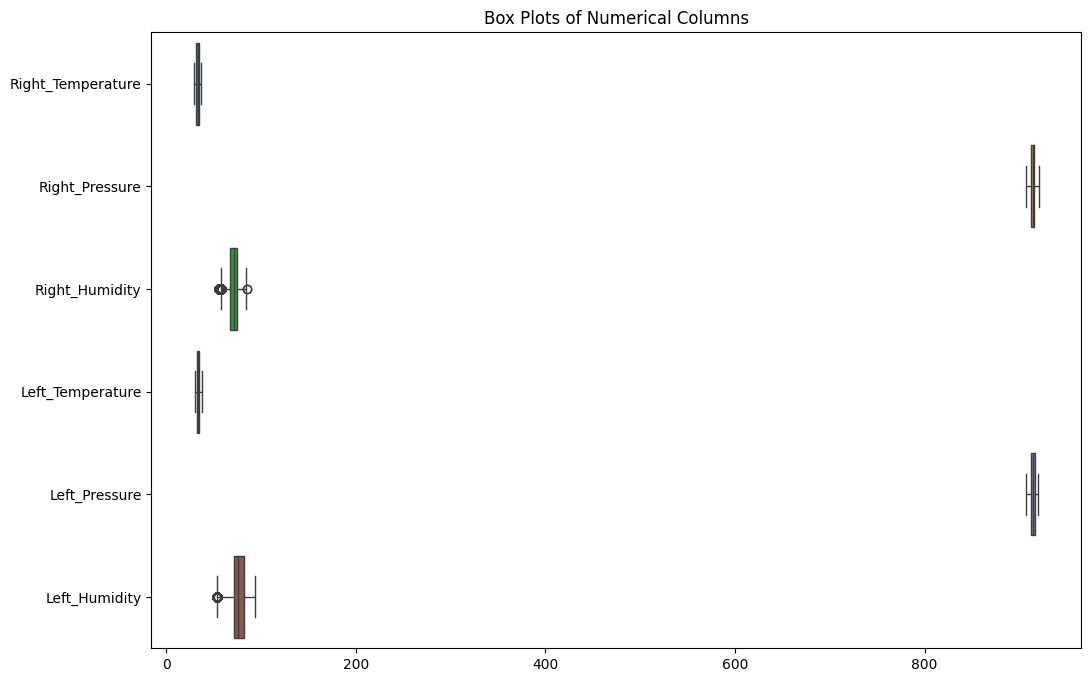

In [19]:
# Generate a horizontal boxplot using Seaborn to visualize the distribution of numerical columns
import matplotlib.pyplot as plt
import seaborn as sns

numerical_columns = ['Right_Temperature', 'Right_Pressure', 'Right_Humidity', 'Left_Temperature', 'Left_Pressure', 'Left_Humidity']

plt.figure(figsize=(12, 8))
sns.boxplot(data=data[numerical_columns], orient='h')
plt.title('Box Plots of Numerical Columns')
plt.show()


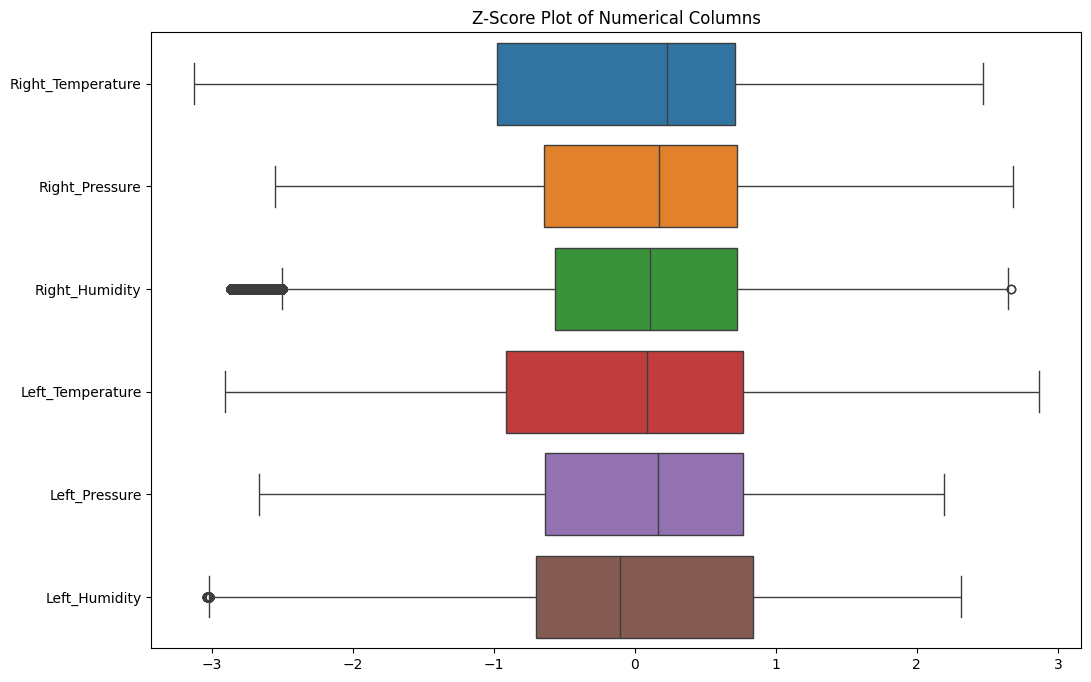

In [20]:
# Create a horizontal boxplot using Seaborn to visualize the distribution of z-scores
from scipy.stats import zscore

plt.figure(figsize=(12, 8))
z_scores = zscore(data[numerical_columns])
sns.boxplot(data=z_scores, orient='h')
plt.title('Z-Score Plot of Numerical Columns')
plt.show()


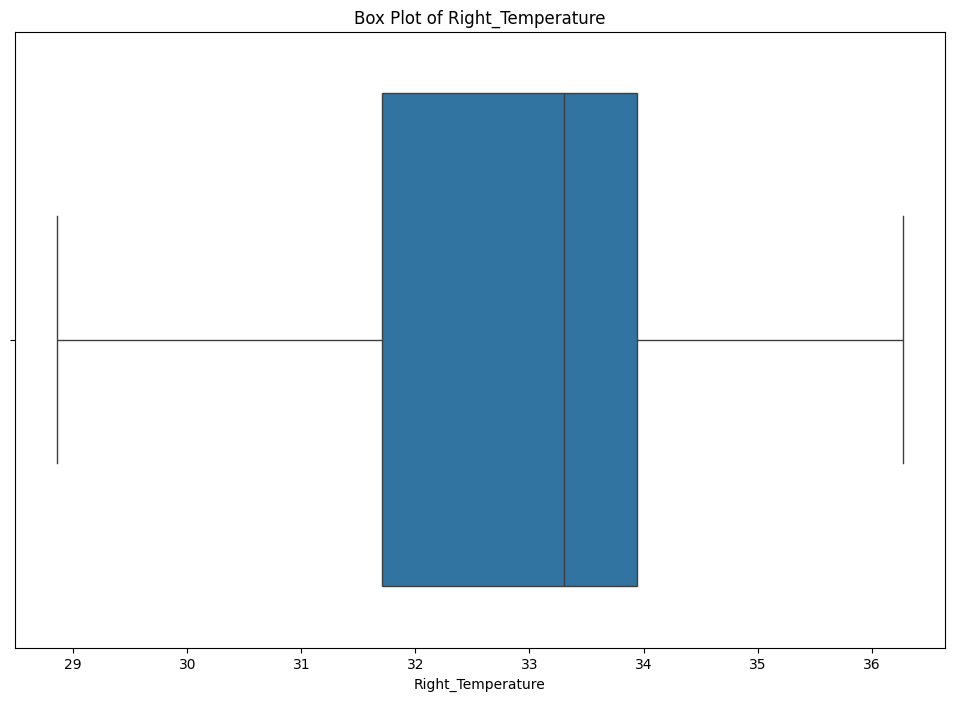

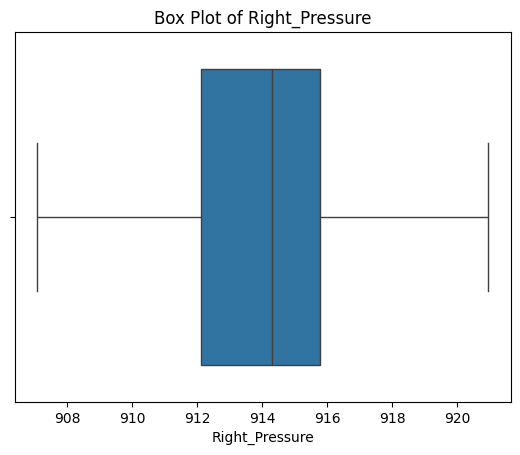

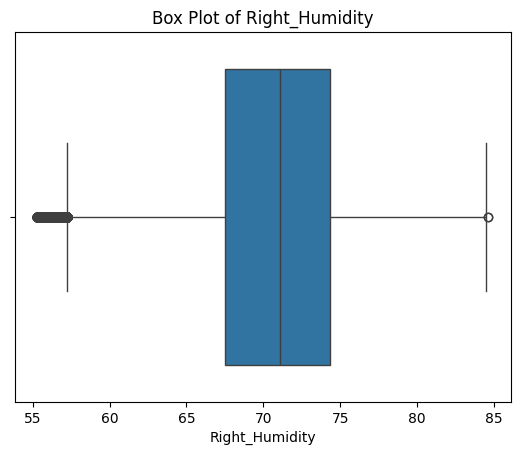

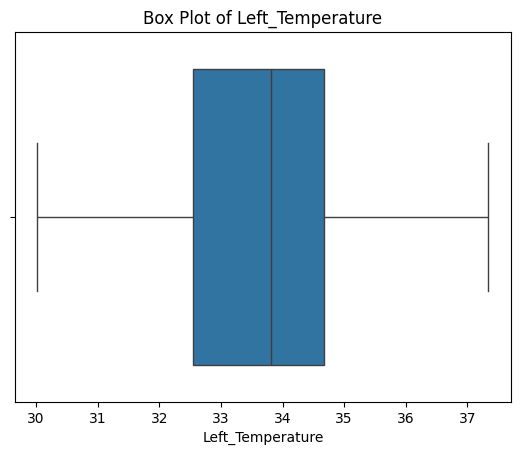

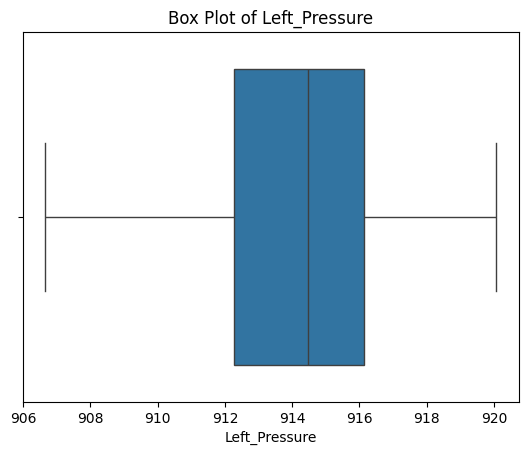

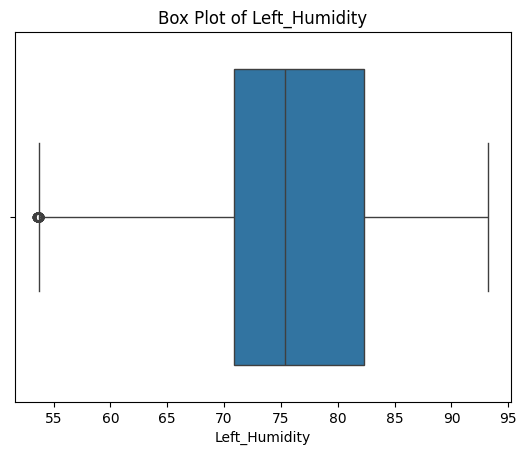

In [21]:
# Visualize box plots for numerical columns to chcek if the outliers are removed
numerical_columns = ['Right_Temperature', 'Right_Pressure', 'Right_Humidity', 'Left_Temperature', 'Left_Pressure', 'Left_Humidity']
plt.figure(figsize=(12, 8))
for column in numerical_columns:
    sns.boxplot(x=data[column])
    plt.title(f'Box Plot of {column}')
    plt.show()

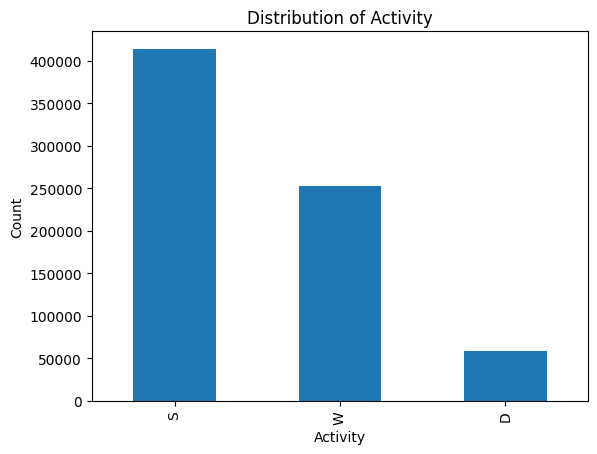

In [22]:
# Visualize the distribution of the 'Activity' column
data['Activity'].value_counts().plot(kind='bar')
plt.xlabel('Activity')
plt.ylabel('Count')
plt.title('Distribution of Activity')
plt.show()


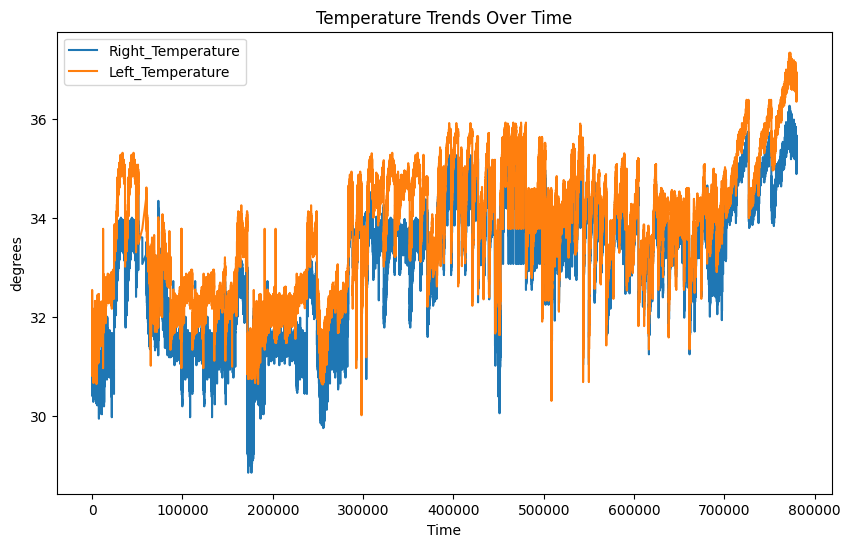

In [23]:
# Visualize temperature trends over time
plt.figure(figsize=(10, 6))
plt.plot(data['Right_Temperature'], label='Right_Temperature')
plt.plot(data['Left_Temperature'], label='Left_Temperature')
plt.xlabel('Time')
plt.ylabel('degrees')
plt.title('Temperature Trends Over Time')
plt.legend()
plt.show()


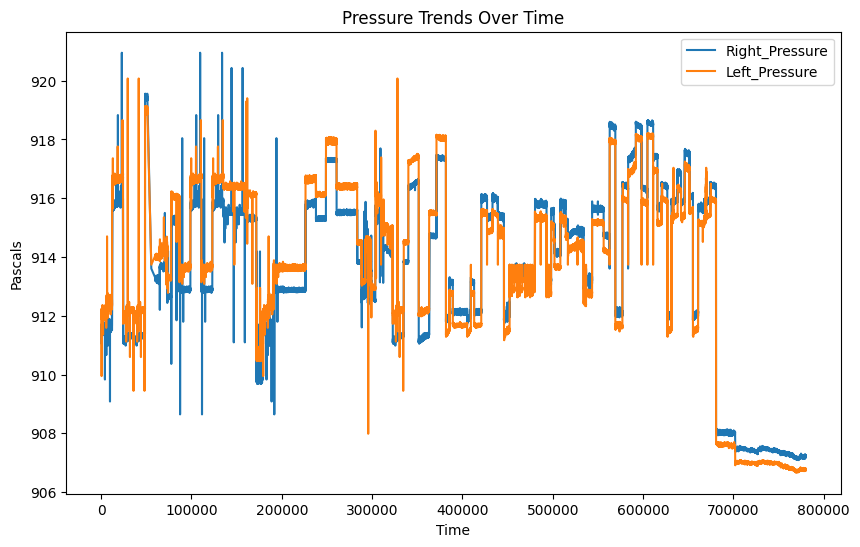

In [24]:
# Visualize pressure trends over time
plt.figure(figsize=(10, 6))
plt.plot(data['Right_Pressure'], label='Right_Pressure')
plt.plot(data['Left_Pressure'], label='Left_Pressure')
plt.xlabel('Time')
plt.ylabel('Pascals')
plt.title('Pressure Trends Over Time')
plt.legend()
plt.show()

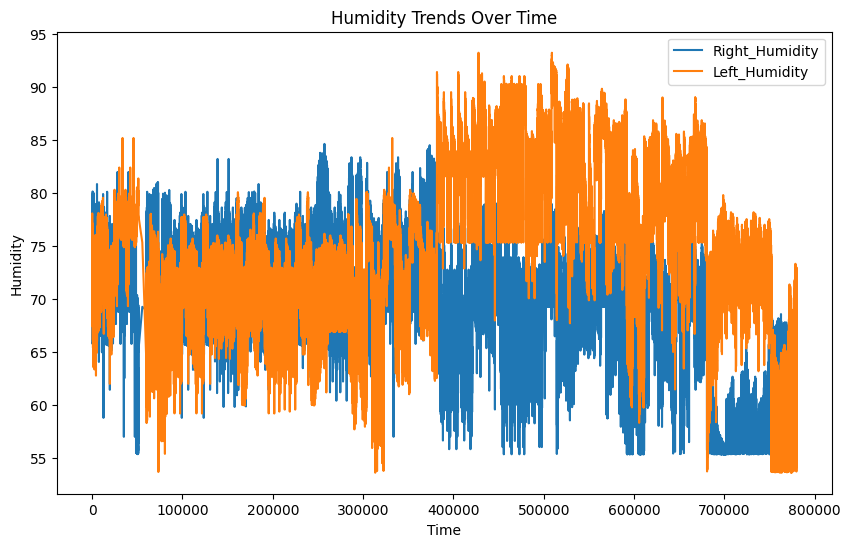

In [25]:
# Visualize humidity trends over time
plt.figure(figsize=(10, 6))
plt.plot(data['Right_Humidity'], label='Right_Humidity')
plt.plot(data['Left_Humidity'], label='Left_Humidity')
plt.xlabel('Time')
plt.ylabel('Humidity')
plt.title('Humidity Trends Over Time')
plt.legend()
plt.show()

In [26]:
# to diaplay all the column names in the dataset
data.columns

Index(['Right_Temperature', 'Right_Pressure', 'Right_Humidity',
       'Left_Temperature', 'Left_Pressure', 'Left_Humidity', 'Activity'],
      dtype='object')

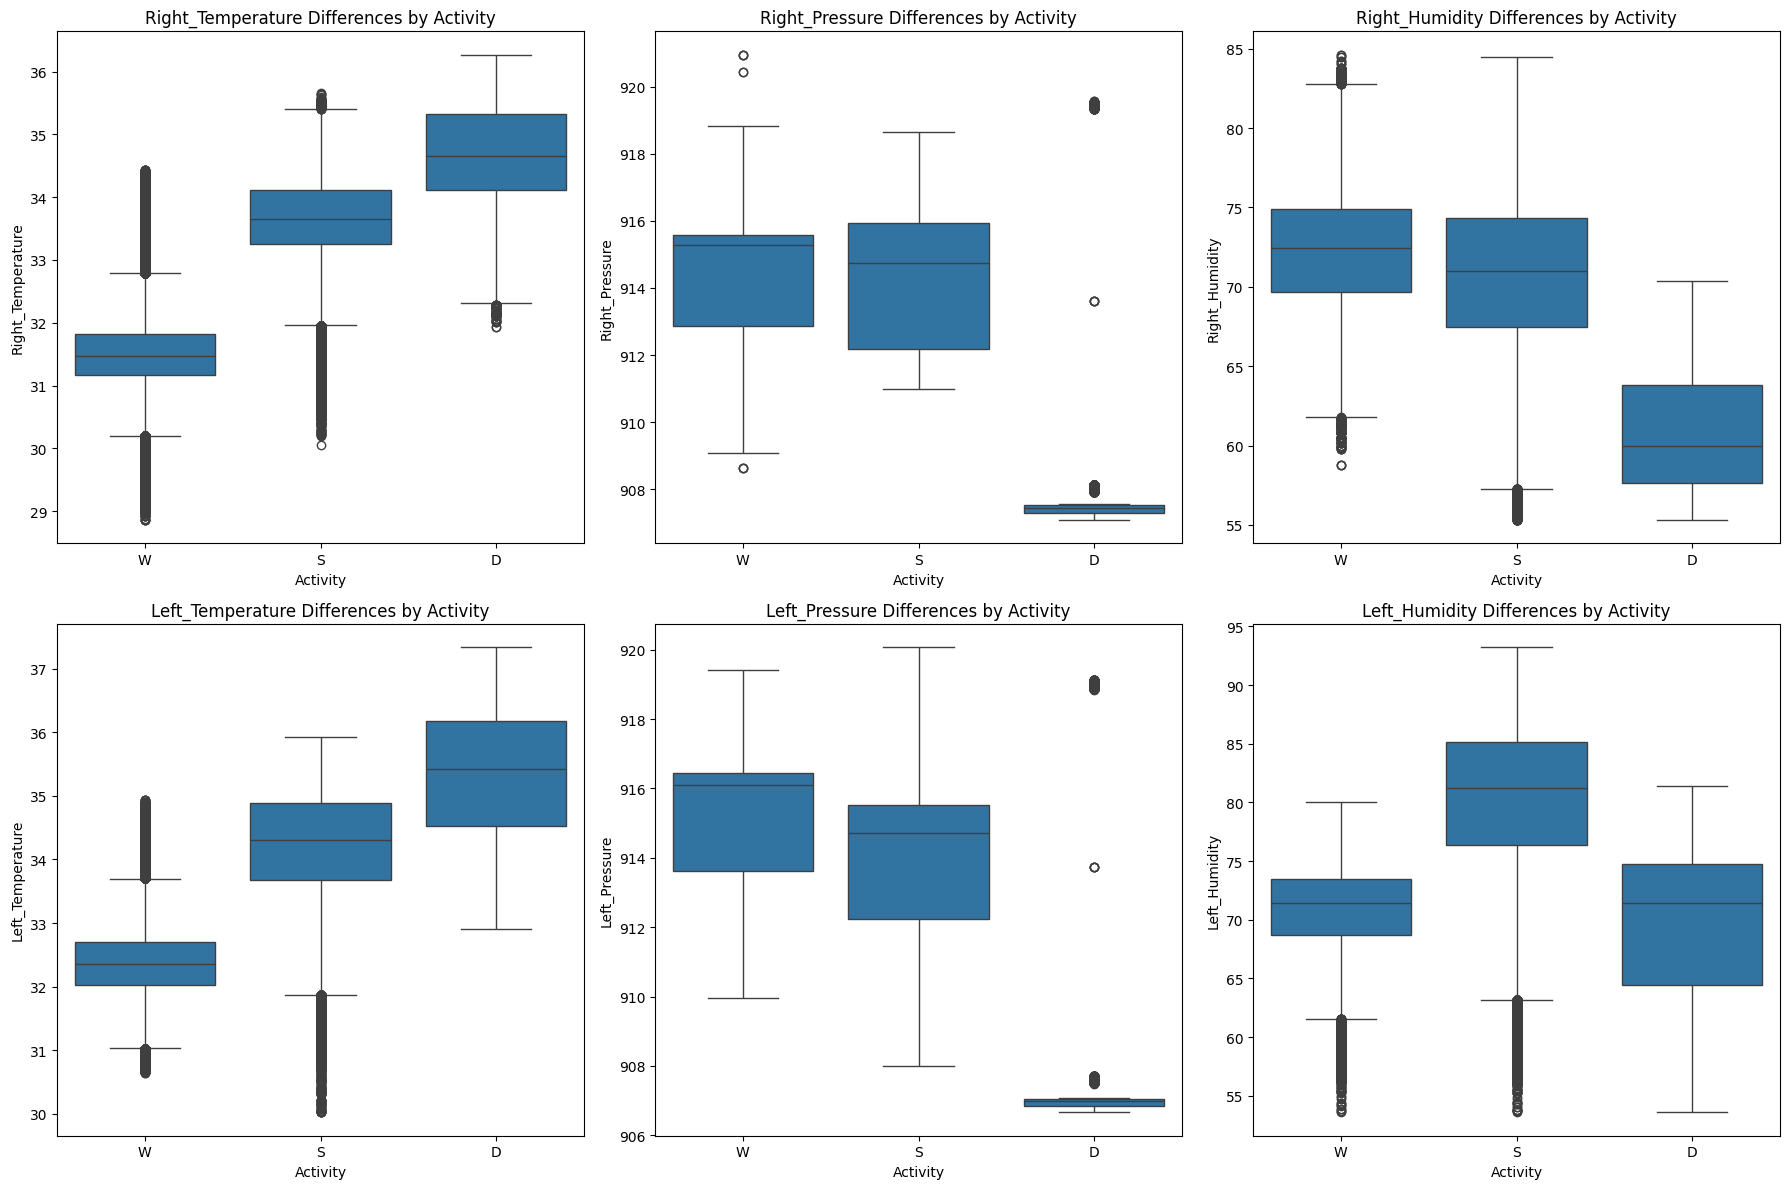

In [27]:
#Dataset understanding with Data Visualisation
# List of features to plot
features = ['Right_Temperature', 'Right_Pressure', 'Right_Humidity', 
            'Left_Temperature', 'Left_Pressure', 'Left_Humidity']

# Set up the plotting grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

# Loop through each feature and plot
for i, feature in enumerate(features):
    sns.boxplot(x='Activity', y=feature, data=data, ax=axes[i])
    axes[i].set_title(f'{feature} Differences by Activity')
    axes[i].set_xlabel('Activity')
    axes[i].set_ylabel(feature)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In [28]:
# Define features and target variable
features = ['Right_Temperature', 'Right_Pressure', 'Right_Humidity', 'Left_Temperature', 'Left_Pressure', 'Left_Humidity']
target = ['Activity']

In [29]:
# importing necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.utils import shuffle

In [30]:
# Split the data into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(data[features],data[target],test_size = 0.2, random_state = 101)

In [31]:
# Perform oversampling using SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [32]:
# Ensure that the target variable is a 1D array
y_train_resampled = y_train_resampled.values.ravel()

In [33]:
# Shuffle the training data to avoid potential biases
X_train_resampled, y_train_resampled = shuffle(X_train_resampled, y_train_resampled, random_state=101)

In [34]:
# Use Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=10, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(n_estimators=10, random_state=42)

In [35]:
# Make predictions on the test set
predictions_rf = rf_model.predict(X_test)
predictions_rf

array(['S', 'W', 'S', ..., 'S', 'S', 'S'], dtype=object)

In [36]:
# Example input for prediction
input = [[33.44,908.0875,55.28,33.42,907.6713,52.99]]
# Make a prediction using the trained model
prediction = rf_model.predict(input)
print(prediction)

['D']


c:\Users\ompat\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [37]:
# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, predictions_rf)
conf_matrix_rf = confusion_matrix(y_test, predictions_rf)
classification_report_rf = classification_report(y_test, predictions_rf)

In [38]:
# Displaying the evaluated values
print(f"Random Forest Accuracy: {accuracy_rf}")
print("Confusion Matrix:")
print(conf_matrix_rf)
print("Classification Report:")
print(classification_report_rf)

Random Forest Accuracy: 0.9873924948100943
Confusion Matrix:
[[11800     2     0]
 [    0 81637   844]
 [    0   982 49728]]
Classification Report:
              precision    recall  f1-score   support

           D       1.00      1.00      1.00     11802
           S       0.99      0.99      0.99     82481
           W       0.98      0.98      0.98     50710

    accuracy                           0.99    144993
   macro avg       0.99      0.99      0.99    144993
weighted avg       0.99      0.99      0.99    144993



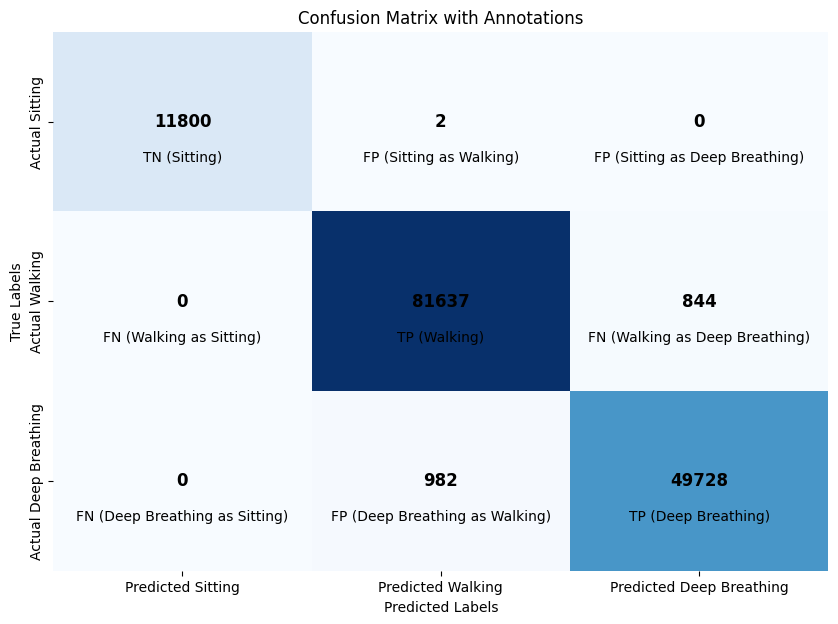

In [39]:
# Plot confusion matrix without annotations
plt.figure(figsize=(10, 7))
ax = sns.heatmap(conf_matrix_rf, annot=False, fmt='d', cmap='Blues', cbar=False, 
                 xticklabels=['Predicted Sitting', 'Predicted Walking', 'Predicted Deep Breathing'], 
                 yticklabels=['Actual Sitting', 'Actual Walking', 'Actual Deep Breathing'])

# Define labels for the confusion matrix cells
labels = np.array([
    ['TN (Sitting)', 'FP (Sitting as Walking)', 'FP (Sitting as Deep Breathing)'], 
    ['FN (Walking as Sitting)', 'TP (Walking)', 'FN (Walking as Deep Breathing)'], 
    ['FN (Deep Breathing as Sitting)', 'FP (Deep Breathing as Walking)', 'TP (Deep Breathing)']
])

# Annotate numbers and labels for each cell separately
for i in range(conf_matrix_rf.shape[0]):
    for j in range(conf_matrix_rf.shape[1]):
        # Add the number
        ax.text(j + 0.5, i + 0.5, conf_matrix_rf[i, j], 
                color='black', ha='center', va='center', 
                fontsize=12, weight='bold')
        # Add the label below the number
        ax.text(j + 0.5, i + 0.7, labels[i, j], 
                color='black', ha='center', va='center', 
                fontsize=10)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix with Annotations')
plt.show()

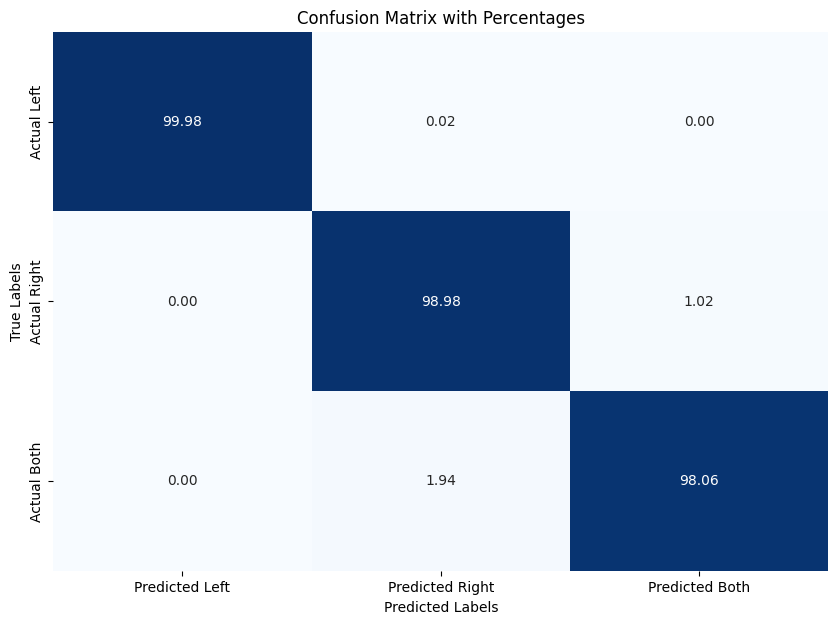

In [40]:
# Calculate confusion matrix percentages
conf_matrix_rf_percent = conf_matrix_rf / conf_matrix_rf.sum(axis=1)[:, np.newaxis] * 100

# Plot confusion matrix with annotations as percentages
plt.figure(figsize=(10, 7))
ax = sns.heatmap(conf_matrix_rf_percent, annot=True, fmt='.2f', cmap='Blues', cbar=False, 
                 xticklabels=['Predicted Left', 'Predicted Right', 'Predicted Both'], 
                 yticklabels=['Actual Left', 'Actual Right', 'Actual Both'])

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix with Percentages')
plt.show()

In [41]:
# Accuracy of the model
accuracy = accuracy_score(y_test, predictions_rf)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9873924948100943


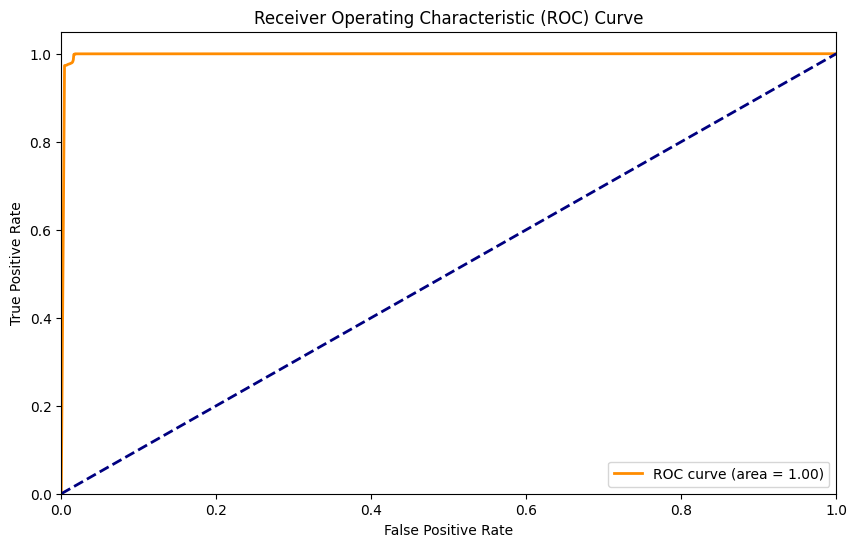

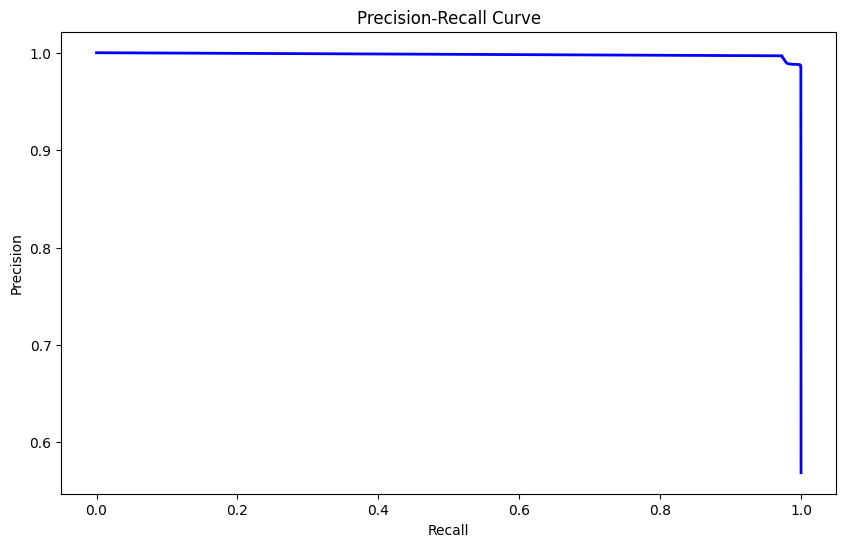

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Calculate the ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1], pos_label=rf_model.classes_[1])
roc_auc = auc(fpr, tpr)

# Calculate the Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, rf_model.predict_proba(X_test)[:, 1], pos_label=rf_model.classes_[1])

# Plot the ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Plot the Precision-Recall curve
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


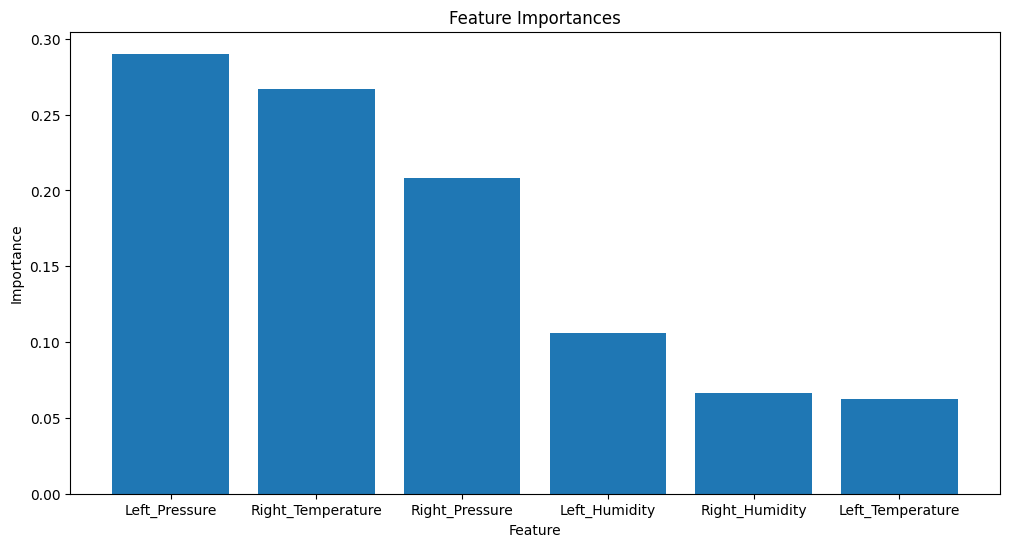

In [43]:
# Feature Importance Plot
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title('Feature Importances')
plt.bar(range(X_train_resampled.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train_resampled.shape[1]), [features[i] for i in indices])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.show()

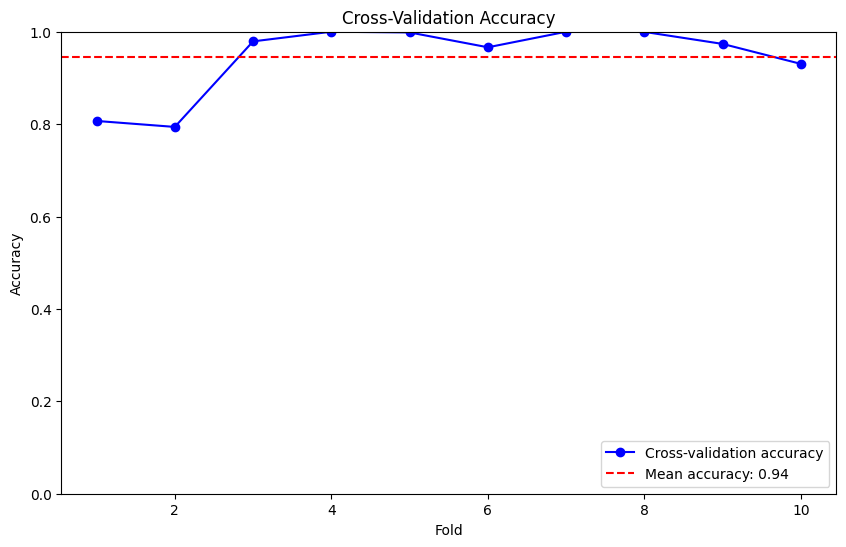

Cross-validation accuracies: [0.80687477 0.7939363  0.97910258 1.         0.99845509 0.9662878
 1.         0.99959998 0.97354337 0.93028581]
Mean cross-validation accuracy: 0.9448085688677285


In [44]:
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# Perform 10-fold cross-validation
cv_scores = cross_val_score(rf_model, data[features], data['Activity'], cv=10, scoring='accuracy')

# Plot the cross-validation accuracy scores
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), cv_scores, marker='o', linestyle='-', color='b', label='Cross-validation accuracy')
plt.axhline(y=np.mean(cv_scores), color='r', linestyle='--', label=f'Mean accuracy: {np.mean(cv_scores):.2f}')
plt.ylim([0, 1])
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

print(f'Cross-validation accuracies: {cv_scores}')
print(f'Mean cross-validation accuracy: {np.mean(cv_scores)}')


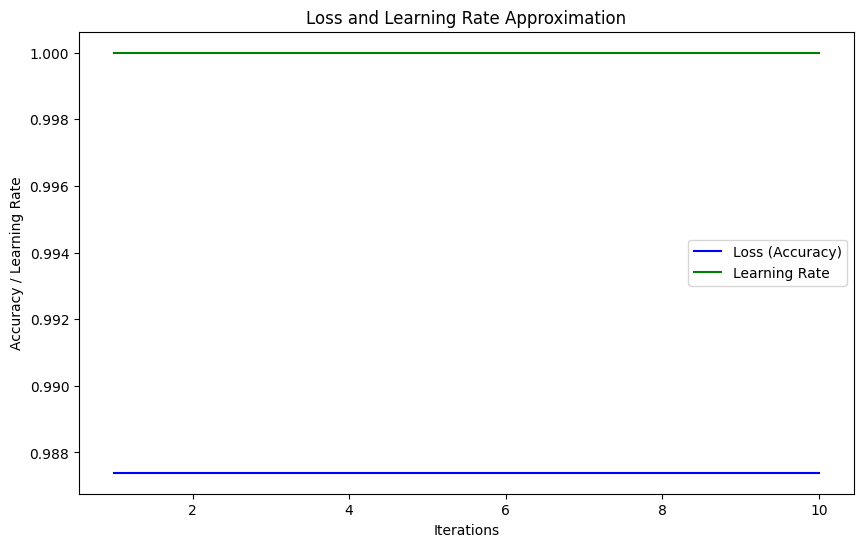

In [45]:
# Plot Loss, Learning Rate, and Epoch Curve (approximation for RandomForestClassifier)
# As RandomForestClassifier doesn't have these concepts directly, we can approximate them with iterations
iterations = range(1, len(rf_model.estimators_) + 1)
loss = [accuracy_rf] * len(iterations)  # Since RandomForestClassifier doesn't have a loss function
learning_rate = [1] * len(iterations)   # Constant learning rate for RandomForestClassifier
plt.figure(figsize=(10, 6))
plt.plot(iterations, loss, label='Loss (Accuracy)', color='blue')
plt.plot(iterations, learning_rate, label='Learning Rate', color='green')
plt.xlabel('Iterations')
plt.ylabel('Accuracy / Learning Rate')
plt.title('Loss and Learning Rate Approximation')
plt.legend()
plt.show()

In [46]:
prediction_proba = rf_model.predict_proba(input)
print(f"Prediction Probabilities: {prediction_proba}")

Prediction Probabilities: [[1. 0. 0.]]


c:\Users\ompat\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [47]:
# Labeling the prediction probabilities
labels = rf_model.classes_
proba_percent = prediction_proba[0] * 100
proba_dict = {label: f"{prob:.2f}%" for label, prob in zip(labels, proba_percent)}

In [48]:
print(f"Prediction: {prediction[0]}")
print(f"Prediction Probabilities: {proba_dict}")

Prediction: D
Prediction Probabilities: {'D': '100.00%', 'S': '0.00%', 'W': '0.00%'}


In [49]:
# Save the trained model to a file
import pickle
pickle.dump(rf_model, open('model2.pkl', 'wb'))